# Transfer Learning CIFAR10

* Train a simple convnet on the CIFAR dataset the first 5 output classes [0..4].
* Freeze convolutional layers and fine-tune dense layers for the last 5 ouput classes [5..9].


In [1]:
import keras
import  tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


Using TensorFlow backend.


In [0]:

import warnings
warnings.filterwarnings("ignore")

### 1. Import CIFAR10 data and create 2 datasets with one dataset having classes from 0 to 4 and other having classes from 5 to 9 

In [0]:
from keras.datasets import cifar10

In [4]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

170500096/170498071 [==============================] - 3s 0us/step


In [5]:
print('shape of train_images',train_images.shape)
print('shape of test_images',test_images.shape)
print('shape of train_labels',train_labels.shape)
print('shape of test_labels',test_labels.shape)

shape of train_images (50000, 32, 32, 3)
shape of test_images (10000, 32, 32, 3)
shape of train_labels (50000, 1)
shape of test_labels (10000, 1)


In [0]:
cifar10_labels = [ "airplane",  # index 0
                   "automobile",   # index 1
                   "bird",   # index 2 
                   "cat",   # index 3 
                   "deer",    # index 4
                   "dog",    # index 5
                   "frog",     # index 6 
                   "horse",   # index 7 
                   "ship",   # index 8 
                   "truck"]   # index 9

In [0]:
def plot_images(image_label_tuple, grid_nums):
    plt.figure(figsize=(2*grid_nums, 2*grid_nums))
    for i in range(grid_nums**2):
        plt.subplot(grid_nums, grid_nums, i+1)
        plt.imshow(image_label_tuple[0][i], cmap='gray')
        plt.colorbar()
        plt.xticks([])
        plt.yticks([])
        plt.xlabel(cifar10_labels[image_label_tuple[1][i][0]])
        plt.grid(False)
    plt.show()  

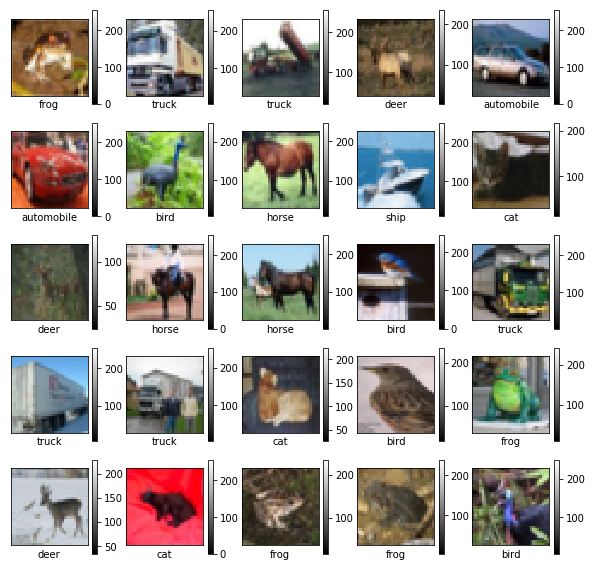

In [10]:
plot_images((train_images, train_labels),5)

In [0]:
train_images_0_4 = np.array([train_images[i] for i, x in enumerate(train_labels.tolist()) if x[0] < 5])
test_images_0_4 = np.array([test_images[i] for i, x in enumerate(test_labels.tolist()) if x[0] < 5])
train_labels_0_4 = np.array([train_labels[i] for i, x in enumerate(train_labels.tolist()) if x[0] < 5])
test_labels_0_4 = np.array([test_labels[i] for i, x in enumerate(test_labels.tolist()) if x[0] < 5])

In [0]:
train_images_5_9 = np.array([train_images[i] for i, x in enumerate(train_labels.tolist()) if x[0] >= 5])
test_images_5_9 = np.array([test_images[i] for i, x in enumerate(test_labels.tolist()) if x[0] >= 5])
train_labels_5_9 = np.array([train_labels[i] for i, x in enumerate(train_labels.tolist()) if x[0] >= 5])
test_labels_5_9 = np.array([test_labels[i] for i, x in enumerate(test_labels.tolist()) if x[0] >= 5])

In [16]:
train_images_0_4.shape
test_images_0_4.shape

(5000, 32, 32, 3)

In [17]:
# Split dataset of interest (labels 0-4)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(train_images_0_4, train_labels_0_4, test_size=0.20, random_state=42)
print("Training data size (0-4): {} images".format(len(y_train)))

Training data size (0-4): 20000 images


### 2. Use One-hot encoding to divide y_train and y_test into required no of output classes

In [0]:
y_train = tf.keras.utils.to_categorical(y_train)
y_test  = tf.keras.utils.to_categorical(y_test)

### 3. Build a sequential neural network model which can classify the classes 0 to 4 of CIFAR10 dataset with at least 80% accuracy on test data

In [19]:
# Build a sequential neural network model which can classify the classes 0 to 4 of CIFAR10 dataset
# Initialize a sequential model
tf.keras.backend.clear_session()

# Initialize model, reshape & normalize the data
model = tf.keras.models.Sequential()

# Reshape the data
model.add(tf.keras.layers.Reshape(target_shape=(32,32,3), input_shape=(32,32,3))) # RESHAPE

# Normalize the data
model.add(tf.keras.layers.BatchNormalization()) # NORMALIZATION

# Add first convolutional layer
model.add(tf.keras.layers.Conv2D(32, # Num of convolutional feature-maps or num of filters
                                 kernel_size=(3,3), # Filter size
                                 activation='relu'))

# Add 2nd Convolutional layer
model.add(tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))

# Add MaxPooling layer
model.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))

# Flatten the output
model.add(tf.keras.layers.Flatten())

# Add first Dense layer
model.add(tf.keras.layers.Dense(128, activation='relu'))

# Add Droput layer
model.add(tf.keras.layers.Dropout(rate=0.2))

# Add output layer
model.add(tf.keras.layers.Dense(5, activation='softmax'))

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


In [20]:
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape (Reshape)            (None, 32, 32, 3)         0         
_________________________________________________________________
batch_normalization (BatchNo (None, 32, 32, 3)         12        
_________________________________________________________________
conv2d (Conv2D)              (None, 30, 30, 32)        896       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 28, 28, 64)        18496     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 14, 14, 64)        0         
_________________________________________________________________
flatten (Flatten)            (None, 12544)             0         
_________________________________________________________________
dense (Dense)                (None, 128)               1

In [0]:
# Need at least 80% accuracy on test data
# Early stopping
from keras.callbacks import EarlyStopping
es = EarlyStopping(monitor='val_acc', baseline=0.8, patience=100)

# ModelCheckpoint
from keras.callbacks import ModelCheckpoint
mc = ModelCheckpoint('best_model.h5', monitor='val_acc', mode='max', verbose=1, save_best_only=True)

In [28]:
# Fit model
model.fit(X_train, y_train, batch_size=1000, 
          validation_data=(X_test, y_test), shuffle=True, epochs=10, callbacks=[es, mc])

Train on 20000 samples, validate on 5000 samples
Epoch 1/10
19000/20000 [===========================>..] - ETA: 3s - loss: 0.2536 - acc: 0.9148
Epoch 00001: val_acc improved from 0.76560 to 0.77600, saving model to best_model.h5
20000/20000 [==============================] - 81s 4ms/sample - loss: 0.2526 - acc: 0.9154 - val_loss: 0.6701 - val_acc: 0.7760
Epoch 2/10
19000/20000 [===========================>..] - ETA: 3s - loss: 0.2352 - acc: 0.9228
Epoch 00002: val_acc did not improve from 0.77600
20000/20000 [==============================] - 80s 4ms/sample - loss: 0.2363 - acc: 0.9228 - val_loss: 0.6793 - val_acc: 0.7746
Epoch 3/10
19000/20000 [===========================>..] - ETA: 3s - loss: 0.2364 - acc: 0.9212
Epoch 00003: val_acc did not improve from 0.77600
20000/20000 [==============================] - 81s 4ms/sample - loss: 0.2360 - acc: 0.9219 - val_loss: 0.6754 - val_acc: 0.7740
Epoch 4/10
19000/20000 [===========================>..] - ETA: 3s - loss: 0.2286 - acc: 0.9239
Ep

In [29]:
# Evaluate model
# load the saved model
saved_model = tf.keras.models.load_model('best_model.h5')

# evaluate the model
_, train_acc = saved_model.evaluate(X_train, y_train, verbose=0)
_, test_acc = saved_model.evaluate(X_test, y_test, verbose=0)
print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Train: 0.963, Test: 0.777


### 4. In the model which was built above (for classification of classes 0-4 in CIFAR10), make only the dense layers to be trainable and conv layers to be non-trainable

In [30]:
# Transfer learning 
# Load pretrained model
baseModel = tf.keras.models.load_model('best_model.h5')

# show a summary of the base model
print("[INFO] summary for base model...")
print(baseModel.summary())

[INFO] summary for base model...
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape (Reshape)            (None, 32, 32, 3)         0         
_________________________________________________________________
batch_normalization (BatchNo (None, 32, 32, 3)         12        
_________________________________________________________________
conv2d (Conv2D)              (None, 30, 30, 32)        896       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 28, 28, 64)        18496     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 14, 14, 64)        0         
_________________________________________________________________
flatten (Flatten)            (None, 12544)             0         
_________________________________________________________________
dense (Dense)          

In [0]:
# Make only dense layers trainable
def layer_output(model, layer_name=None):
  """
  Output tensor of a specific layer in a model.
  """
  conv_index = -1

  for i in range(len(model.layers) - 1, -1, -1):
      layer = model.layers[i]
      if layer_name in layer.name:
          conv_index = i
          break

  if conv_index < 0:
      print('Error: could not find the interested layer.')

  return model.layers[conv_index].output

# construct the head of the model that will be placed on top of the the base model
headModel = layer_output(baseModel, 'max_pooling2d')

### 5. Utilize the the model trained on CIFAR 10 (classes 0 to 4) to classify the classes 5 to 9 of CIFAR 10  (Use Transfer Learning) <br>
Achieve an accuracy of more than 85% on test data

In [33]:
# Split dataset of interest (labels 5-9)
X_train, X_test, y_train, y_test = train_test_split(train_images_5_9, train_labels_5_9, test_size=0.20, random_state=42)
print("Training data size (0-4): {} images".format(len(y_train)))

Training data size (0-4): 20000 images


In [0]:
# Use One-hot encoding to divide y_train and y_test into required no of output classes
# Restructure labels for one-hot encoding
y_train = y_train - 5
y_test = y_test - 5

# One-hot encoder
y_train = tf.keras.utils.to_categorical(y_train)
y_test  = tf.keras.utils.to_categorical(y_test)

In [35]:
# Flatten the output
headModel = tf.keras.layers.Flatten()(headModel)

headModel = tf.keras.layers.Dense(128, activation='relu')(headModel)
headModel = tf.keras.layers.Dropout(0.2)(headModel)
headModel = tf.keras.layers.Dense(5, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(0.01))(headModel)

# place the head FC model on top of the base model (this will become the actual model we will train)
model_new = tf.keras.models.Model(inputs=baseModel.input, outputs=headModel)

# loop over all layers in the base model and freeze them so they will
# *not* be updated during the first training process
for layer in baseModel.layers:
    layer.trainable = False
    
# compile our model (this needs to be done after our setting our layers to being non-trainable)
model_new.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
# summarize layers
print(model_new.summary())

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape_input (InputLayer)   [(None, 32, 32, 3)]       0         
_________________________________________________________________
reshape (Reshape)            (None, 32, 32, 3)         0         
_________________________________________________________________
batch_normalization (BatchNo (None, 32, 32, 3)         12        
_________________________________________________________________
conv2d (Conv2D)              (None, 30, 30, 32)        896       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 28, 28, 64)        18496     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 14, 14, 64)        0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 12544)             0     

In [37]:
# Need at least 85% accuracy on test data
# Early stopping
from keras.callbacks import EarlyStopping
es = EarlyStopping(monitor='val_acc', baseline=0.85)

# ModelCheckpoint
from keras.callbacks import ModelCheckpoint
mc = ModelCheckpoint('best_model_2.h5', monitor='val_acc', mode='max', verbose=1, save_best_only=True)

model_new.fit(X_train, y_train, batch_size=1000, 
          validation_data=(X_test, y_test), shuffle=True, epochs=10, callbacks=[mc])

Train on 20000 samples, validate on 5000 samples
Epoch 1/10
19000/20000 [===========================>..] - ETA: 1s - loss: 0.6782 - acc: 0.7846
Epoch 00001: val_acc improved from -inf to 0.77880, saving model to best_model_2.h5
20000/20000 [==============================] - 27s 1ms/sample - loss: 0.6777 - acc: 0.7845 - val_loss: 0.6902 - val_acc: 0.7788
Epoch 2/10
19000/20000 [===========================>..] - ETA: 1s - loss: 0.6657 - acc: 0.7910
Epoch 00002: val_acc did not improve from 0.77880
20000/20000 [==============================] - 28s 1ms/sample - loss: 0.6637 - acc: 0.7916 - val_loss: 0.6874 - val_acc: 0.7766
Epoch 3/10
19000/20000 [===========================>..] - ETA: 1s - loss: 0.6631 - acc: 0.7910
Epoch 00003: val_acc improved from 0.77880 to 0.78420, saving model to best_model_2.h5
20000/20000 [==============================] - 27s 1ms/sample - loss: 0.6625 - acc: 0.7908 - val_loss: 0.6777 - val_acc: 0.7842
Epoch 4/10
19000/20000 [===========================>..] - ETA

In [38]:
# Evaluate model
# load the saved model
saved_model = tf.keras.models.load_model('best_model_2.h5')

# evaluate the model
_, train_acc = saved_model.evaluate(X_train, y_train, verbose=0)
_, test_acc = saved_model.evaluate(X_test, y_test, verbose=0)
print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Train: 0.843, Test: 0.802


# Text classification using TF-IDF

### 6. Load the dataset from sklearn.datasets

In [0]:
from sklearn.datasets import fetch_20newsgroups

In [0]:
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']

### 7. Training data

In [41]:
twenty_train = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)

### 8. Test data

In [0]:
twenty_test = fetch_20newsgroups(subset='test', categories=categories, shuffle=True, random_state=42)

###  a.  You can access the values for the target variable using .target attribute 
###  b. You can access the name of the class in the target variable with .target_names


In [43]:
twenty_train.target

array([1, 1, 3, ..., 2, 2, 2])

In [44]:
twenty_train.target_names

['alt.atheism', 'comp.graphics', 'sci.med', 'soc.religion.christian']

In [45]:
twenty_train.data[0:5]

['From: sd345@city.ac.uk (Michael Collier)\nSubject: Converting images to HP LaserJet III?\nNntp-Posting-Host: hampton\nOrganization: The City University\nLines: 14\n\nDoes anyone know of a good way (standard PC application/PD utility) to\nconvert tif/img/tga files into LaserJet III format.  We would also like to\ndo the same, converting to HPGL (HP plotter) files.\n\nPlease email any response.\n\nIs this the correct group?\n\nThanks in advance.  Michael.\n-- \nMichael Collier (Programmer)                 The Computer Unit,\nEmail: M.P.Collier@uk.ac.city                The City University,\nTel: 071 477-8000 x3769                      London,\nFax: 071 477-8565                            EC1V 0HB.\n',
 "From: ani@ms.uky.edu (Aniruddha B. Deglurkar)\nSubject: help: Splitting a trimming region along a mesh \nOrganization: University Of Kentucky, Dept. of Math Sciences\nLines: 28\n\n\n\n\tHi,\n\n\tI have a problem, I hope some of the 'gurus' can help me solve.\n\n\tBackground of the probl

### 9.  Now with dependent and independent data available for both train and test datasets, using TfidfVectorizer fit and transform the training data and test data and get the tfidf features for both

In [0]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
# TfidfVectorizer
vect = TfidfVectorizer()
twenty_train_df = pd.DataFrame(vect.fit_transform(twenty_train).toarray(), columns=vect.get_feature_names())
twenty_test_df = pd.DataFrame(vect.transform(twenty_test).toarray(), columns=vect.get_feature_names())

### 10. Use logisticRegression with tfidf features as input and targets as output and train the model and report the train and test accuracy score

In [0]:
X_train = twenty_train_df.drop('target_names', axis=1)
y_train = twenty_train_df[['target_names']]
X_test = twenty_test_df.drop('target_names', axis=1)
y_test = twenty_test_df[['target_names']]

In [54]:
# use logistic regression with text column only
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
logreg = LogisticRegression(C=1e9)
logreg.fit(X_train, y_train)

LogisticRegression(C=1000000000.0, class_weight=None, dual=False,
                   fit_intercept=True, intercept_scaling=1, l1_ratio=None,
                   max_iter=100, multi_class='warn', n_jobs=None, penalty='l2',
                   random_state=None, solver='warn', tol=0.0001, verbose=0,
                   warm_start=False)

In [56]:
# report the train and test accuracy score
from sklearn.metrics import accuracy_score
y_predict_train = logreg.predict(X_train)
y_predict_test = logreg.predict(X_test)
print("Training accuracy score: {}".format(accuracy_score(y_train, y_predict_train)))
print("Test accuracy score: {}".format(accuracy_score(y_test, y_predict_test)))

Training accuracy score: 1.0
Test accuracy score: 1.0


In [57]:
# Confusion matrix
GS_cm_train = confusion_matrix(y_train, y_predict_train)
GS_cm_test = confusion_matrix(y_test, y_predict_test)
print("Confusion matrix (train):")
print(GS_cm_train)
print("Confusion matrix (test):")
print(GS_cm_test)

Confusion matrix (train):
[[4 0]
 [0 1]]
Confusion matrix (test):
[[4 0]
 [0 1]]
